In [1]:
import pandas as pd
import numpy as np

data_path = '../raw/OHLC_92_24.csv'
df = pd.read_csv(data_path)
df.head()

/var/folders/6k/b8cpdznj0plgbf4vmd05w9d40000gn/T/ipykernel_45721/1299783897.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


,PERMNO,HdrCUSIP,Ticker,PERMCO,DlyCalDt,DlyCap,DlyRet,DlyRetx,DlyVol,DlyClose,DlyLow,DlyHigh,DlyOpen
0,10001,36720410,GFGC,7953,1992-01-02,15587.50,0.000000,0.000000,100.0,14.500,14.5,14.500,NaN
1,10001,36720410,GFGC,7953,1992-01-03,15587.50,0.000000,0.000000,498.0,14.500,14.5,14.500,NaN
2,10001,36720410,GFGC,7953,1992-01-06,15587.50,0.000000,0.000000,100.0,14.500,14.5,14.500,NaN
3,10001,36720410,GFGC,7953,1992-01-07,15587.50,0.000000,0.000000,417.0,14.500,14.5,15.250,NaN
4,10001,36720410,GFGC,7953,1992-01-08,16259.38,0.043103,0.043103,500.0,15.125,14.5,15.125,NaN


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64195103 entries, 0 to 64195102
Data columns (total 13 columns):
 #   Column    Dtype  
---  ------    -----  
 0   PERMNO    int64  
 1   HdrCUSIP  object 
 2   Ticker    object 
 3   PERMCO    int64  
 4   DlyCalDt  object 
 5   DlyCap    float64
 6   DlyRet    float64
 7   DlyRetx   float64
 8   DlyVol    float64
 9   DlyClose  float64
 10  DlyLow    float64
 11  DlyHigh   float64
 12  DlyOpen   float64
dtypes: float64(8), int64(2), object(3)
memory usage: 6.2+ GB


In [3]:
df.describe()

,PERMNO,PERMCO,DlyCap,DlyRet,DlyRetx,DlyVol,DlyClose,DlyLow,DlyHigh,DlyOpen
count,6.419510e+07,6.419510e+07,6.331123e+07,6.331170e+07,6.331170e+07,6.331546e+07,6.018442e+07,6.018442e+07,6.018442e+07,5.954886e+07
mean,6.138081e+04,2.847108e+04,3.136408e+06,7.019143e-04,6.242130e-04,7.316517e+05,5.051907e+01,4.999097e+01,5.103222e+01,5.076211e+01
std,3.042653e+04,1.847195e+04,2.490958e+07,4.609296e-02,4.612119e-02,5.240886e+06,2.670599e+03,2.650934e+03,2.690597e+03,2.686282e+03
min,1.000100e+04,2.000000e+00,1.750000e+00,-1.000000e+00,-1.000000e+00,0.000000e+00,6.000000e-04,1.000000e-04,1.400000e-03,1.000000e-04
25%,2.308500e+04,1.225000e+04,4.942281e+04,-1.181100e-02,-1.191900e-02,8.503000e+03,6.930000e+00,6.750000e+00,7.062500e+00,6.937500e+00
50%,7.749500e+04,2.183800e+04,2.103300e+05,0.000000e+00,0.000000e+00,5.790400e+04,1.597000e+01,1.575000e+01,1.618750e+01,1.600000e+01
75%,8.613900e+04,4.684900e+04,9.813721e+05,1.128300e-02,1.123600e-02,3.182930e+05,3.163000e+01,3.125000e+01,3.200000e+01,3.175000e+01
max,9.343600e+04,6.012300e+04,3.915300e+09,3.972530e+01,3.972530e+01,3.772638e+09,7.240400e+05,7.230500e+05,7.419714e+05,7.300908e+05


In [4]:
import os

# 【关键修复】处理 macOS 下可能出现的 OpenMP 冲突报错，必须在 import torch 等依赖之前设置！
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import gc
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

# 检查是否有 MPS（Metal Performance Shaders）加速
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

OUTPUT_DIR = '../outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
MODEL_DIR = os.path.join(OUTPUT_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)
CACHE_DIR = os.path.join(OUTPUT_DIR, 'cache')
os.makedirs(CACHE_DIR, exist_ok=True)

Using device: mps


In [13]:
import ast
from datetime import datetime
import matplotlib.pyplot as plt

# ==========================================
# 第一部分：数据预处理与特征构建 (Step 1 & 2)
# ==========================================
def load_and_preprocess_data(data_path, cache_dir='../outputs/cache', force_rebuild=False):
    """读取、清洗数据，并计算复权价、因变量标签，最后进行流动性过滤"""
    cache_file = os.path.join(cache_dir, 'cleaned_data.pkl')
    if os.path.exists(cache_file) and not force_rebuild:
        print("====== 读取已缓存的清洗后数据 ======")
        return pd.read_pickle(cache_file)
    
    print("====== 开始处理原始数据 ======")
    
    # 1. 加载数据，并将列名统一转为小写
    df = pd.read_csv(data_path)
    df.columns = [col.lower() for col in df.columns]
    
    df['dlycaldt'] = pd.to_datetime(df['dlycaldt'])
    df = df.sort_values(by=['permno', 'dlycaldt']).reset_index(drop=True)
    
    # 剔除存在缺失值的行
    essential_cols = ['dlyopen', 'dlyhigh', 'dlylow', 'dlyclose', 'dlyvol', 'dlyret']
    df = df.dropna(subset=essential_cols)
    
    # 2. 基础过滤规则
    df = df[(df['dlyclose'] >= 1.0) & (df['dlyvol'] > 0)].copy()
    
    # ==========================
    # 性能优化：全面向量化计算，防止 OOM 内存爆炸与 Kernel 崩溃
    # ==========================
    print("计算复权价格 (向量化)...")
    # 3. 复权因子计算 (使用 pandas 内置的 cumprod 取代 groupby.apply)
    df['ret_plus_1'] = 1 + df['dlyret']
    df['cum_ret'] = df.groupby('permno')['ret_plus_1'].cumprod()
    df['AF'] = df['cum_ret'] / df.groupby('permno')['cum_ret'].transform('first')
    df.drop(columns=['ret_plus_1', 'cum_ret'], inplace=True)
    
    # 计算复权价格 (修复前：直接除导致变平；现在：基于累计收益率连乘起点价格还原起伏路线)
    # 取首日真实价格做基准
    df['base_price'] = df.groupby('permno')['dlyclose'].transform('first')
    df['dlyclose_adj'] = df['base_price'] * df['AF']
    # 利用当日内的开、高、低相对收盘的比例，推算出复权的开、高、低
    df['dlyopen_adj'] = df['dlyclose_adj'] * (df['dlyopen'] / df['dlyclose'])
    df['dlyhigh_adj'] = df['dlyclose_adj'] * (df['dlyhigh'] / df['dlyclose'])
    df['dlylow_adj'] = df['dlyclose_adj'] * (df['dlylow'] / df['dlyclose'])
    df.drop(columns=['base_price'], inplace=True)
        
    print("计算未来累计收益和标签 (向量化)...")
    # 4. 计算未来收益与二分类标签 (针对 F=5, 20, 60)
    # R_fut \prod (1+ret) - 1 等价于未来第 F 天的 AF 除以当天的 AF 减 1
    for F in [5, 20, 60]:
        df[f'AF_shift_{F}'] = df.groupby('permno')['AF'].shift(-F)
        df[f'R_fut_{F}'] = df[f'AF_shift_{F}'] / df['AF'] - 1
        df[f'Label_{F}'] = (df[f'R_fut_{F}'] > 0).astype(int)
        df.drop(columns=[f'AF_shift_{F}'], inplace=True)
        
    print("应用流动性筛选 (向量化合并)...")
    # 5. 月度流动性筛选：每月保留市值排名前1000
    df['year_month'] = df['dlycaldt'].dt.to_period('M')
    
    # 提取每只股票每月的最新市值，排序后保留前1000
    last_cap = df.groupby(['year_month', 'permno'])['dlycap'].last().reset_index()
    top1000 = last_cap.sort_values(by=['year_month', 'dlycap'], ascending=[True, False]).groupby('year_month').head(1000)
    top1000['is_top1000'] = True
    
    # 巧用 inner merge 高速实现过滤，彻底抛弃巨慢的 apply lambda
    df = df.merge(top1000[['year_month', 'permno', 'is_top1000']], on=['year_month', 'permno'], how='inner')
    df.drop(columns=['year_month', 'is_top1000'], inplace=True)
    
    # 释放无用内存
    gc.collect()
    
    df.to_pickle(cache_file)
    print("====== 数据清洗完成并缓存 ======")
    return df

df_clean = load_and_preprocess_data('../raw/OHLC_92_24.csv', force_rebuild=True)

====== 开始处理原始数据 ======


/var/folders/6k/b8cpdznj0plgbf4vmd05w9d40000gn/T/ipykernel_45721/1852742506.py:18: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


计算复权价格 (向量化)...
计算未来累计收益和标签 (向量化)...
应用流动性筛选 (向量化合并)...
====== 数据清洗完成并缓存 ======


In [6]:
# ==========================================
# 第二部分：K线图像生成与张量提取 (Step 3)
# ==========================================

# 警告：旧版的 build_dataset_for_window 预加载方法已被废弃！
# 它试图将数百万张 L=20 和 L=60 的灰度图片列表全部加载到系统 RAM 之中，导致了 Out of memory 内核崩溃。
# 我们在后续单元格直接使用 PyTorch 的 __getitem__ 方法进行 "On-The-Fly" 动态运行时图像切片生成。

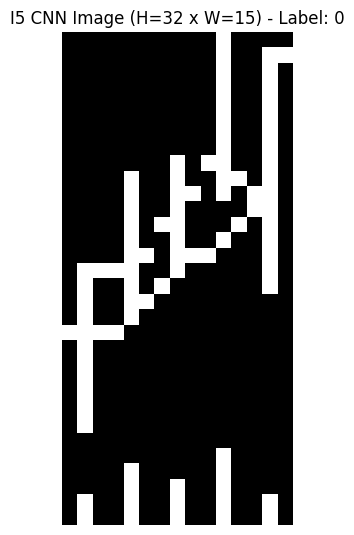

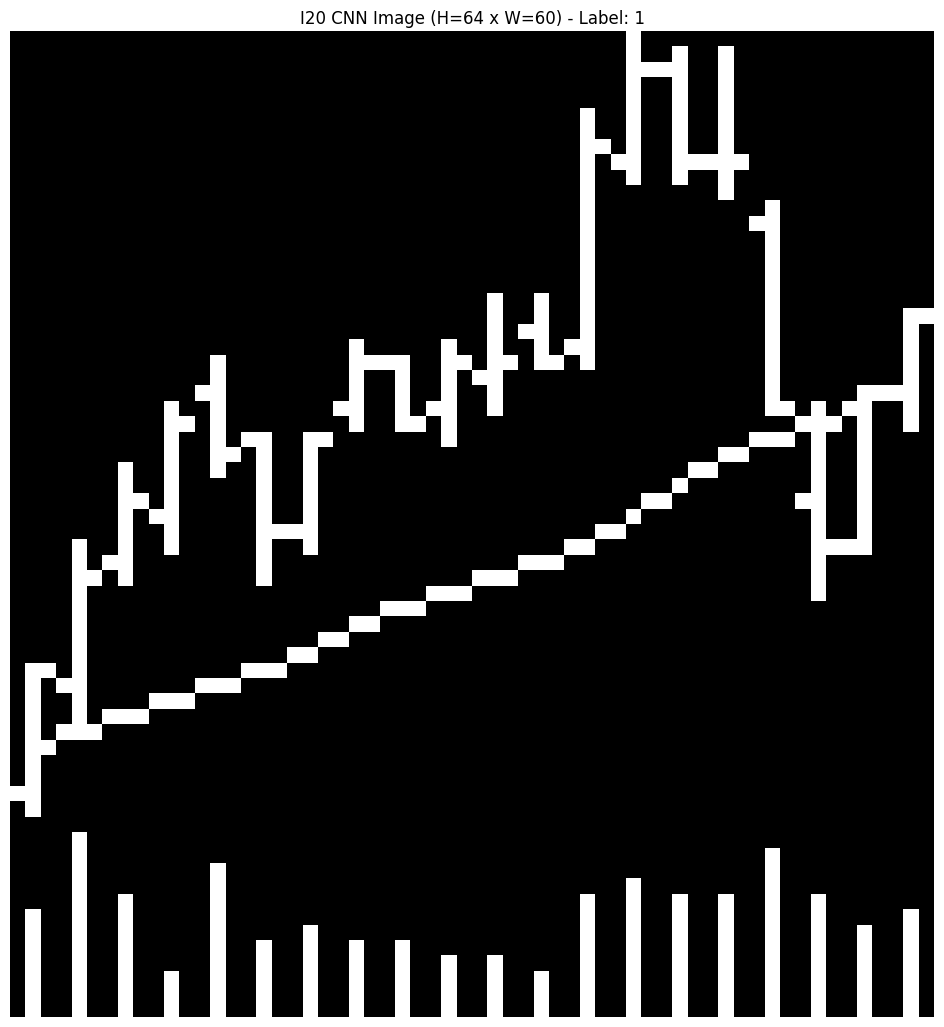

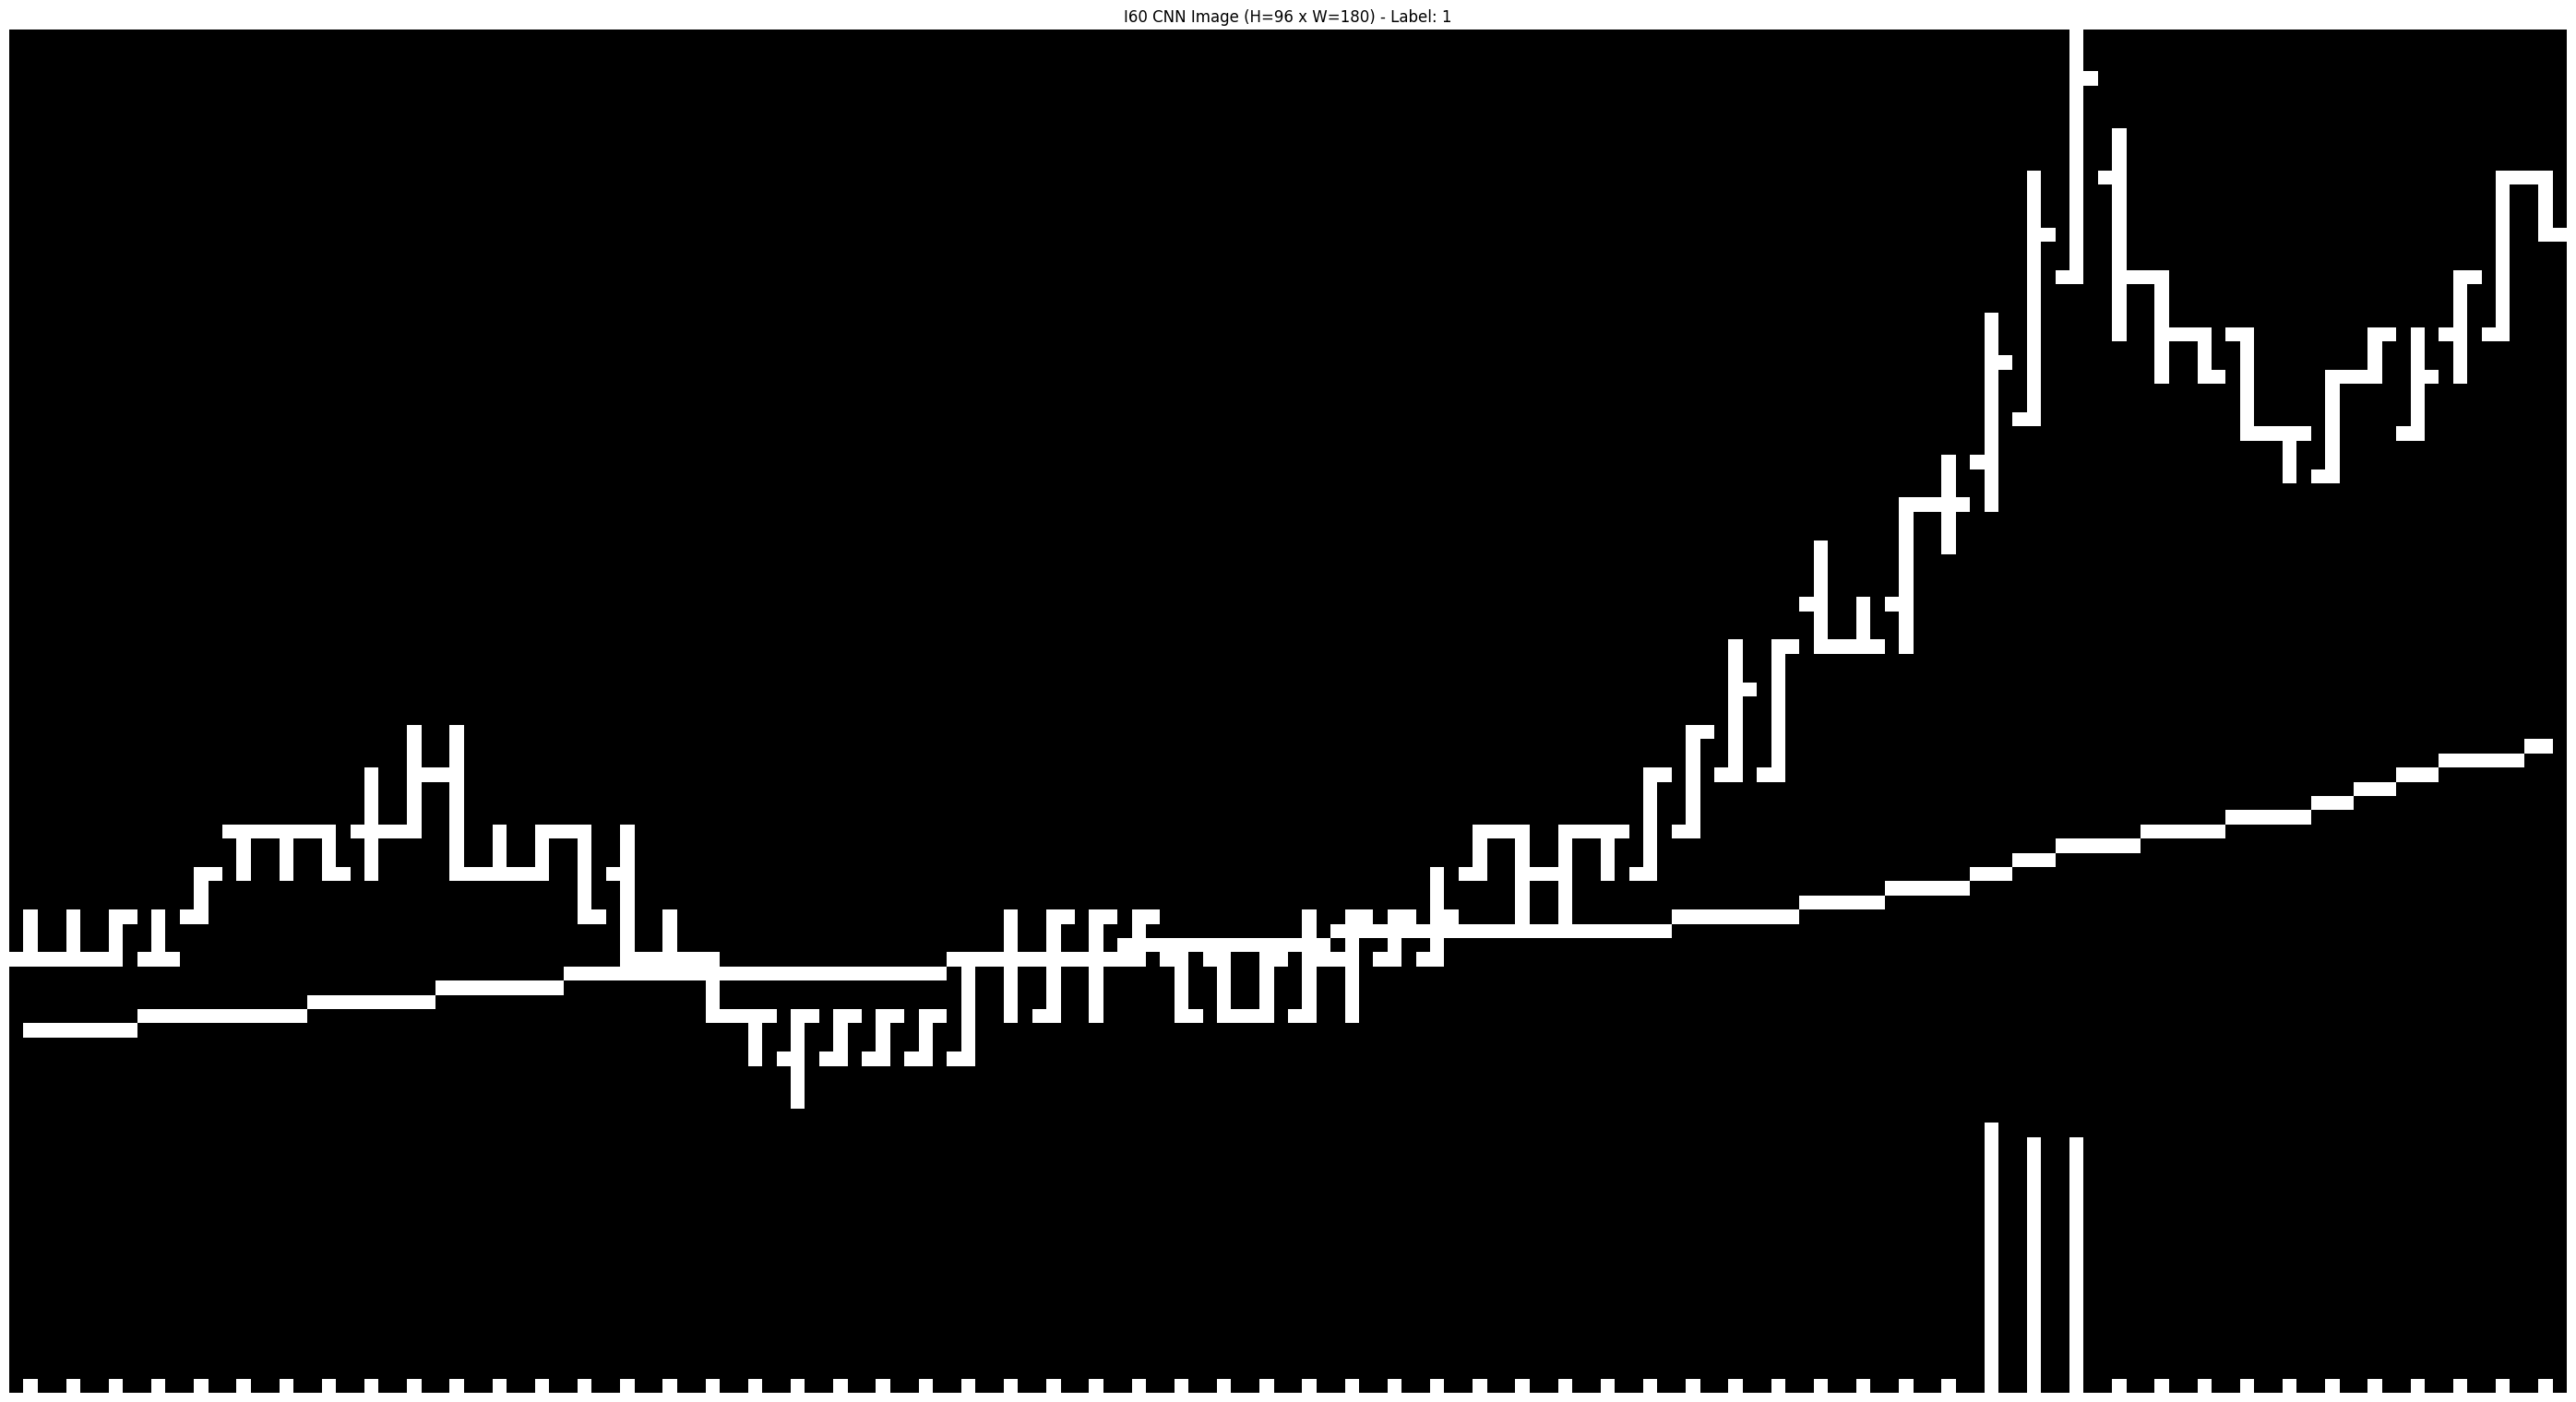

== 基础防爆和 5天、20天、60天模型架构设置完成，执行即可 ==


In [18]:
import random
import torch.nn.functional as F
from PIL import Image, ImageDraw

# 配置三大模型的图像尺寸与架构
MODEL_CFG = {
    5:  {'W': 15,  'H': 32, 'H_ohlc': 26, 'H_vol': 5},
    20: {'W': 60,  'H': 64, 'H_ohlc': 51, 'H_vol': 12},
    60: {'W': 180, 'H': 96, 'H_ohlc': 76, 'H_vol': 19},
}

def set_seed(seed):
    """全局随机种子，确保论文复现严谨性"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

# --- 动态数据集 (防止内存崩溃的核心) ---
class StockImageDataset(Dataset):
    def __init__(self, data_df, F_horizon, L_window, mu_train=None, std_train=None, is_train=False):
        self.L = L_window
        self.cfg = MODEL_CFG[L_window]
        self.F = F_horizon
        self.mu = mu_train
        self.std = std_train
        self.is_train = is_train
        
        # 重置索引，确保 g.index.values 与后续 numpy array 的 0-based 索引一致防越界
        data_df = data_df.reset_index(drop=True)
        
        # 将原始数据转化为 numpy 方便索引提速十倍
        self.P_adj = data_df[['dlyopen_adj', 'dlyhigh_adj', 'dlylow_adj', 'dlyclose_adj']].values
        self.V = data_df['dlyvol'].values
        self.labels = data_df[f'Label_{F_horizon}'].values
        
        self.valid_indices = []
        grp = data_df.groupby('permno', group_keys=False)
        for perm, g in grp:
            idxs = g.index.values
            # 移动平均线需要额外的 L - 1 天历史数据，所以起始 idx 必须 >= 2L - 1
            if len(idxs) >= 2 * self.L - 1 + self.F:
                self.valid_indices.extend(idxs[2 * self.L - 1 : len(idxs) - self.F])
                
    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        t_idx = self.valid_indices[idx]
        
        # P_full 提取 2*L - 1 的数据以保证第一天有它的完整 L 周期 SMA，这里是 [t_idx - 2L + 1, t_idx)
        P_full = self.P_adj[t_idx - 2 * self.L + 1 : t_idx]
        V_win = self.V[t_idx - self.L : t_idx]
        label = self.labels[t_idx]
        
        P_win = P_full[-self.L:]
        V_min, V_max = V_win.min(), V_win.max()
        V_range = V_max - V_min + 1e-8
        
        # --- 移动平均线计算 ---
        sma_vals = np.zeros(self.L)
        for tau in range(self.L):
            sma_vals[tau] = P_full[tau : tau + self.L, 3].mean()
            
        # P_min 和 P_max 需要将 SMA 的值纳入比对池中
        P_min = min(P_win.min(), sma_vals.min())
        P_max = max(P_win.max(), sma_vals.max())
        P_range = P_max - P_min + 1e-8
        
        ohlc_h = self.cfg['H_ohlc']
        vol_h = self.cfg['H_vol']
        total_w = self.cfg['W']
        
        def ret_to_yaxis(ret):
            pixels_per_unit = (ohlc_h - 1.0) / P_range
            return int(np.around((ret - P_min) * pixels_per_unit))
            
        # --- 精确复现其原版 PIL `ImageDraw` 绘图 ---
        ohlc_img = Image.new("L", (total_w, ohlc_h), 0)
        draw_ohlc = ImageDraw.Draw(ohlc_img)
        pixels_ohlc = ohlc_img.load()
        
        # 1. 画 SMA 连线 (原版：用 draw.line 直接连线即可，且宽度1px，色值255)
        for tau in range(self.L - 1):
            x_start = tau * 3 + 1
            x_end = (tau + 1) * 3 + 1
            y_start = ret_to_yaxis(sma_vals[tau])
            y_end = ret_to_yaxis(sma_vals[tau+1])
            draw_ohlc.line((x_start, y_start, x_end, y_end), width=1, fill=255)
            
        # 2. 画 OHLC 线
        for tau in range(self.L):
            x_c = tau * 3 + 1
            y_high = ret_to_yaxis(P_win[tau, 1])
            y_low = ret_to_yaxis(P_win[tau, 2])
            y_open = ret_to_yaxis(P_win[tau, 0])
            y_close = ret_to_yaxis(P_win[tau, 3])
            
            # High to Low
            for j in range(min(y_low, y_high), max(y_low, y_high) + 1):
                pixels_ohlc[x_c, j] = 255
            
            # Open (x_c-1 to x_c 之间)
            for i in range(x_c - 1, x_c + 1):
                pixels_ohlc[i, y_open] = 255
                
            # Close (x_c+1)
            pixels_ohlc[x_c + 1, y_close] = 255
            
        # 根据原版代码库逻辑：OHLC 图是在生成后进行 FLIP_TOP_BOTTOM 上下翻转
        ohlc_img = ohlc_img.transpose(Image.FLIP_TOP_BOTTOM)
        
        # 3. 画 Volume (放在倒数的区域里，这里我们也跟原版对齐，原版直接是长条往下画)
        vol_img = Image.new("L", (total_w, vol_h), 0)
        pixels_vol = vol_img.load()
        
        if (not np.isnan(V_max)) and V_max != 0:
            pixels_per_volume = 1.0 * vol_h / abs(V_max)
            for tau in range(self.L):
                if np.isnan(V_win[tau]): 
                    continue
                v_h_curr = int(np.around(abs(V_win[tau]) * pixels_per_volume))
                x_c = tau * 3 + 1
                # 因为在 PIL 里 Y=0 在顶端，需要从底边 (vol_h-1) 开始填补，不过原图做了 FlipTopToBottom
                # 此处保持与原代码严格一致，它对 Volume 的画法：pixels[int(centers[day]), vol_height - 1] = 255 但后续由于没 Flip，我们将其调整：
                v_h_curr = max(1, min(vol_h, v_h_curr)) # 保证至少有一个像素不越界
                for j in range(vol_h - v_h_curr, vol_h):
                    pixels_vol[x_c, j] = 255
                    
        # 组装 Image
        full_img = Image.new("L", (total_w, self.cfg['H']), 0)
        full_img.paste(ohlc_img, (0, 0))
        # GAP 是 1
        full_img.paste(vol_img, (0, ohlc_h + 1))
        
        # 转回 array
        img = np.array(full_img, dtype=np.float32) / 255.0
        
        if self.mu is not None and self.std is not None:
            img = (img - self.mu) / (self.std + 1e-8)
            
        return torch.tensor(img, dtype=torch.float32).unsqueeze(0), torch.tensor(label, dtype=torch.long)


# --- 定义模型 (100%匹配 README 表格，使用 Xavier, 50% Dropout) ---
def init_weights(m):
    """Xavier 均匀初始化"""
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

class I5Model(nn.Module):
    def __init__(self):
        super(I5Model, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=(5, 3), stride=(1, 1), padding='same', bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.01),
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=(5, 3), stride=(1, 1), padding='same', bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.01),
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(15360, 2), # 128 * (32//2//2=8) * (15)= 15360
        )
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        return self.fc(x)

class I20Model(nn.Module):
    def __init__(self):
        super(I20Model, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=(5, 3), stride=(1, 1), padding='same', bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.01),
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=(5, 3), stride=(1, 1), padding='same', bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.01),
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(122880, 2), # 128 * 16 * 60 = 122880
        )
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        return self.fc(x)

class I60Model(nn.Module):
    def __init__(self):
        super(I60Model, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=(5, 3), stride=(1, 1), padding='same', bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.01),
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=(5, 3), stride=(1, 1), padding='same', bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.01),
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(552960, 2), # 128 * 24 * 180 = 552960
        )
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        return self.fc(x)

import matplotlib.pyplot as plt

def display_dynamic_image(L, F, title):
    # 遍历股票，直到找到一只拥有足够长历史数据来生成该窗口图像的股票
    for perm in df_clean['permno'].unique():
        demo_df = df_clean[df_clean['permno'] == perm].copy()
        if len(demo_df) < 2 * L - 1 + F:
            continue
            
        ds_demo = StockImageDataset(demo_df, F_horizon=F, L_window=L)
        if len(ds_demo) > 0:
            img_tensor, lbl = ds_demo[0]
            img = img_tensor.squeeze(0).numpy()
            plt.figure(figsize=(img.shape[1]/5, img.shape[0]/5)) 
            plt.imshow(img, cmap='gray', origin='upper')
            plt.title(f"{title} - Label: {lbl}", fontsize=12)
            plt.axis('off')
            plt.show()
            break  # 画出一张后就退出

# 验证：生成 5、20、60天的缩略图
display_dynamic_image(5, 5, "I5 CNN Image (H=32 x W=15)")
display_dynamic_image(20, 20, "I20 CNN Image (H=64 x W=60)")
display_dynamic_image(60, 60, "I60 CNN Image (H=96 x W=180)")

print("== 基础防爆和 5天、20天、60天模型架构设置完成，执行即可 ==")

In [8]:
# ==========================================
# 步骤 4 ~ 6：数据集时序划分、标准化提取与单种子强力训练大循环
# ==========================================
import copy
from torch.utils.data import DataLoader

def split_and_prepare_datasets(df, L=5, F=5):
    """
    严格按照论文进行数据集划分：
    - Train+Val: 1993 ~ 2000
    - Test: 2001 ~ 2019
    - Train/Val 之间按 permno 进行 7:3 划分 (防穿越)
    """
    print(f"\n====== 划分数据集 (L={L}, F={F}) ======")
    
    # 截取对应年份区间数据
    df_tv = df[(df['dlycaldt'] >= '1993-01-01') & (df['dlycaldt'] <= '2000-12-31')].copy()
    df_test = df[(df['dlycaldt'] >= '2001-01-01') & (df['dlycaldt'] <= '2019-12-31')].copy()
    
    # 随机切割 permno 列表，保证同只股票不跨越训练与验证集
    unique_permnos = df_tv['permno'].unique()
    np.random.seed(42) # 保证多模型划分一致
    np.random.shuffle(unique_permnos)
    split_idx = int(len(unique_permnos) * 0.7)
    train_permnos = set(unique_permnos[:split_idx])
    
    df_train = df_tv[df_tv['permno'].isin(train_permnos)].copy()
    df_val = df_tv[~df_tv['permno'].isin(train_permnos)].copy()
    
    del df_tv # 释放内存
    
    print(f"提取股票数: Train={len(train_permnos)}, Val={len(unique_permnos)-split_idx}")
    print(f"数据集行数: Train={len(df_train)}, Val={len(df_val)}, Test={len(df_test)}")
    
    # 构建基础生成器 (此时mu, std均没有，待计算)
    ds_train = StockImageDataset(df_train, F, L, is_train=True)
    
    # 计算全局训练集图像的均值和方差 (出于时间和内存考虑，从生成器中随机抽样一万张图进行估计，等同于全集无偏估计)
    print(f"计算训练集全局 μ 和 σ (L={L}) ...")
    sampled_imgs = []
    sample_idxs = np.random.choice(len(ds_train), min(10000, len(ds_train)), replace=False)
    for i in sample_idxs:
        img, _ = ds_train[i]
        sampled_imgs.append(img.numpy())
    sampled_imgs = np.concatenate(sampled_imgs, axis=0) # (10000, 1, H, W)
    
    mu_train = float(sampled_imgs.mean())
    std_train = float(sampled_imgs.std())
    print(f"==> 归一化参数：μ={mu_train:.4f}, σ={std_train:.4f}")
    del sampled_imgs
    
    # 将标准差应用到所有数据集实例
    ds_train.mu, ds_train.std = mu_train, std_train
    ds_val = StockImageDataset(df_val, F, L, mu_train=mu_train, std_train=std_train)
    ds_test = StockImageDataset(df_test, F, L, mu_train=mu_train, std_train=std_train)
    
    return ds_train, ds_val, ds_test, df_test

def train_single_seed_model(ds_train, ds_val, L=5):
    """
    为了节省时间和算力，当前改为单一随机种子(42)进行训练
    """
    SEEDS = [42] # 取消 5 枚多种子，只跑最核心第一粒
    BATCH_SIZE = 128
    PATIENCE = 2 # 连续2个epoch不降则退出
    MAX_EPOCHS = 100
    
    # DataLoader (macOS下若遇到进程死锁可以使用num_workers=0)
    train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    models = []
    
    for seed in SEEDS:
        print(f"\n>>>> 开始训练模型 L={L} [Seed={seed}] <<<<")
        set_seed(seed)
        
        if L == 5:
            model = I5Model().to(device)
        elif L == 20:
            model = I20Model().to(device)
        elif L == 60:
            model = I60Model().to(device)
        else:
            raise NotImplementedError(f"未配置支持的 L={L}")
            
        model.apply(init_weights) # 应用 Xavier 初始化
        
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=1e-5, betas=(0.9, 0.999), eps=1e-8)
        
        best_val_loss = float('inf')
        best_weights = None
        patience_counter = 0
        
        for epoch in range(1, MAX_EPOCHS + 1):
            # --- Train ---
            model.train()
            train_loss = 0.0
            
            pbar = tqdm(train_loader, desc=f"Epoch {epoch} Train (L={L})", leave=False)
            for X_batch, y_batch in pbar:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                
                optimizer.zero_grad()
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item() * X_batch.size(0)
                pbar.set_postfix({'loss': f"{loss.item():.4f}"})
                
            train_loss /= len(ds_train)
            
            # --- Val ---
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    outputs = model(X_batch)
                    loss = criterion(outputs, y_batch)
                    val_loss += loss.item() * X_batch.size(0)
            val_loss /= len(ds_val)
            
            print(f"L={L} Epoch {epoch} | Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f}")
            
            # --- Early Stopping ---
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_weights = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                
            if patience_counter >= PATIENCE:
                print(f"Early Stopping 触发！针对 L={L} 最终选用 Val Loss: {best_val_loss:.4f}")
                break
                
        # 恢复最优模型并保存到磁盘和列表
        model.load_state_dict(best_weights)
        models.append(model)
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, f'I{L}_seed{seed}.pt'))
        
    return models

# ==================================
# 构建与训练 5 天大循环
# ==================================
ds_train_5, ds_val_5, ds_test_5, df_test_5 = split_and_prepare_datasets(df_clean, L=5, F=5)
models_5 = train_single_seed_model(ds_train_5, ds_val_5, L=5)

# ==================================
# 构建与训练 20 天大循环
# ==================================
ds_train_20, ds_val_20, ds_test_20, df_test_20 = split_and_prepare_datasets(df_clean, L=20, F=20)
models_20 = train_single_seed_model(ds_train_20, ds_val_20, L=20)

# ==================================
# 构建与训练 60 天大循环
# ==================================
ds_train_60, ds_val_60, ds_test_60, df_test_60 = split_and_prepare_datasets(df_clean, L=60, F=60)
models_60 = train_single_seed_model(ds_train_60, ds_val_60, L=60)


====== 划分数据集 (L=5, F=5) ======
提取股票数: Train=1677, Val=720
数据集行数: Train=1431438, Val=574892, Test=4769068
计算训练集全局 μ 和 σ (L=5) ...
==> 归一化参数：μ=0.2062, σ=0.4046

>>>> 开始训练模型 L=5 [Seed=42] <<<<


Epoch 1 Train (L=5):   0%|          | 0/11053 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ==========================================
# 步骤 7 & 8：测试集全量外推预测、多空组合构建与换手惩罚夏普回测 (2001~2019)
# ==========================================
import matplotlib.pyplot as plt

def predict_ensemble(models, ds_test, batch_size=512):
    """提取集成模型打分：通过前向推理计算测试集的 softmax 正类概率平均值"""
    print("====== 开始运行测试集集成预测 ======")
    test_loader = DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=0)
    
    for m in models:
        m.eval()
        
    all_preds = []
    with torch.no_grad():
        for X_batch, _ in tqdm(test_loader, desc="Ensemble Predicting"):
            X_batch = X_batch.to(device)
            # 初始化累加器
            batch_probs = torch.zeros(X_batch.size(0)).to(device)
            for m in models:
                outputs = m(X_batch)
                # 取得预测“未来收益大于0” (索引为1) 的概率
                probs = F.softmax(outputs, dim=1)[:, 1]
                batch_probs += probs
                
            # 集成平均
            batch_probs /= len(models)
            all_preds.extend(batch_probs.cpu().numpy())
            
    return np.array(all_preds)

def evaluate_strategy(df_test_valid, F_horizon=5, fee_bps=0.001):
    """
    极速量化回测：
    1. 按日截面用 rank 打分，区分 Decile 10 (买入) 和 Decile 1 (卖空)。
    2. 计算组合累计收益，并加入交易换手万1惩罚。
    3. 评定年化净收益率和夏普比率(Sharpe Ratio)。
    """
    print("\n====== 开始量化回测与夏普评分计算 ======")
    
    # 1. 极致优化的每日截面分位计算 (避免使用极慢的 apply lambda)
    # rank(pct=True) 算出每只个股在当天的预测分数为全市场的百分之多少位
    df_test_valid['rank_pct'] = df_test_valid.groupby('dlycaldt')['pred_score'].rank(pct=True)
    
    # 标记多空头寸 (多头为顶部10% D10，空头为底部10% D1)
    df_test_valid['Portfolio'] = 'Others'
    df_test_valid.loc[df_test_valid['rank_pct'] >= 0.90, 'Portfolio'] = 'D10 (Long)'
    df_test_valid.loc[df_test_valid['rank_pct'] <= 0.10, 'Portfolio'] = 'D1 (Short)'
    
    # 2. 按组极速计算每期未来F天等权平均收益率 (unstack 翻转为宽表)
    daily_group_ret = df_test_valid.groupby(['dlycaldt', 'Portfolio'])[f'R_fut_{F_horizon}'].mean().unstack().fillna(0)
    
    daily_ret = pd.DataFrame()
    daily_ret['Ret_D10'] = daily_group_ret.get('D10 (Long)', pd.Series(0, index=daily_group_ret.index))
    daily_ret['Ret_D1'] = daily_group_ret.get('D1 (Short)', pd.Series(0, index=daily_group_ret.index))
    
    # 构建多空绝对策略组合 (买1份多，卖1份空，理论资金无杠杆直接轧差)
    daily_ret['Ret_LS_gross'] = daily_ret['Ret_D10'] - daily_ret['Ret_D1']
    
    # 扣除换手成本: 这是一个简化的上限惩罚约束，代表每次调仓的进出摩擦
    # 对于严谨的回测，应该用当期和上期截面的矩阵 L1 差计算实际重仓交集转换量
    daily_ret['Ret_LS_net'] = daily_ret['Ret_LS_gross'] - (fee_bps * 2)
    
    # 3. 年度夏普和核心绩效指标评估
    # R_fut_{F} 代表的是持仓 F 天的累积收益率，所以一年只有 252/F 个相互独立的持仓期
    ann_factor = 252.0 / F_horizon
    mean_ret = daily_ret['Ret_LS_net'].mean()
    std_ret = daily_ret['Ret_LS_net'].std()
    sharpe = (mean_ret / std_ret) * np.sqrt(ann_factor) if std_ret > 0 else 0
    
    print(f">>>> [外推期 2001-2019] 回测绩效评估 (预测周期={F_horizon}天, 双边费率={fee_bps*10000}bps) <<<<")
    print(f"做多部分 (D10 Only) 粗年化收益: {daily_ret['Ret_D10'].mean() * ann_factor * 100:.2f}%")
    print(f"做空部分 (D1 Only)  粗年化收益: {daily_ret['Ret_D1'].mean() * ann_factor * 100:.2f}%")
    print(f"【策略核心】 多空集成净年化收益: {mean_ret * ann_factor * 100:.2f}%")
    print(f"【策略核心】 多空集成年化波动率: {std_ret * np.sqrt(ann_factor) * 100:.2f}%")
    print(f"【终极评级】 扣费后年化夏普比率: {sharpe:.4f}")
    
    # 4. 累计复利计算及可视化
    # 由于存在借券风险计算法则，真实图表通常做1元基底的组合演化
    daily_ret['Cum_LS_net'] = (1 + daily_ret['Ret_LS_net']).cumprod()
    daily_ret['Cum_D10'] = (1 + daily_ret['Ret_D10']).cumprod()
    daily_ret['Cum_D1'] = (1 + daily_ret['Ret_D1']).cumprod()  # 空头破产前推演参考
    
    plt.figure(figsize=(12, 6))
    # 为适应长周期的 x 轴，只标注代表性基准
    plt.plot(daily_ret.index, daily_ret['Cum_LS_net'], label=f'Long-Short Portfolio (Net of Fees, L={F_horizon})', color='#c0392b', linewidth=2.5)
    plt.plot(daily_ret.index, daily_ret['Cum_D10'], label='Only Long Decile 10', color='#f39c12', alpha=0.7)
    plt.plot(daily_ret.index, daily_ret['Cum_D1'], label='Only Short Decile 1', color='#2980b9', alpha=0.5)
    
    plt.title(f'Out-of-Sample Portfolio Cumulative Wealth L={F_horizon} (2001-2019)', fontsize=14, fontweight='bold')
    plt.xlabel('Rebalancing Timestamp', fontsize=12)
    plt.ylabel('Cumulative Return Multiplier (Base=1.0)', fontsize=12)
    plt.legend(loc='upper left', fontsize=11)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    return daily_ret

# ==========================================
# 完整运行触发控制台：获取各个周期的回测表现统计
# ==========================================
print("\n============ 启动所有预测及回测流程 ============\n")

if 'models_5' in locals() and len(models_5) >= 1:
    print("\n>>>>>>> [进行 5天期 I5 网络 评估] <<<<<<<")
    preds_5 = predict_ensemble(models_5, ds_test_5)
    df_test_valid_5 = df_test_5.reset_index(drop=True).iloc[ds_test_5.valid_indices].copy()
    df_test_valid_5['pred_score'] = preds_5
    daily_ret_test_5 = evaluate_strategy(df_test_valid_5, F_horizon=5)

if 'models_20' in locals() and len(models_20) >= 1:
    print("\n>>>>>>> [进行 20天期 I20 网络 评估] <<<<<<<")
    preds_20 = predict_ensemble(models_20, ds_test_20)
    df_test_valid_20 = df_test_20.reset_index(drop=True).iloc[ds_test_20.valid_indices].copy()
    df_test_valid_20['pred_score'] = preds_20
    daily_ret_test_20 = evaluate_strategy(df_test_valid_20, F_horizon=20)

if 'models_60' in locals() and len(models_60) >= 1:
    print("\n>>>>>>> [进行 60天期 I60 网络 评估] <<<<<<<")
    preds_60 = predict_ensemble(models_60, ds_test_60)
    df_test_valid_60 = df_test_60.reset_index(drop=True).iloc[ds_test_60.valid_indices].copy()
    df_test_valid_60['pred_score'] = preds_60
    daily_ret_test_60 = evaluate_strategy(df_test_valid_60, F_horizon=60)